In [1]:
import copy
import json
import os
import pickle
import random
import socket
import subprocess
from datetime import datetime
from pathlib import Path

import imageio
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import display

import robomimic
import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.torch_utils as TorchUtils

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


hostname: mk-c
pid: 3274777
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-09d77f1f-8992-15cc-7b76-e48a47442fcd)


In [2]:
# Load automaton world model, diffusion policy, and environment

DP_CKPT_PATH = "/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth"
AUTOMATON_RUN_DIR = Path("/home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_17-52-27")

assert Path(DP_CKPT_PATH).exists(), f"Policy checkpoint not found: {DP_CKPT_PATH}"
assert (AUTOMATON_RUN_DIR / "best_model.pt").exists(), f"Automaton checkpoint not found: {AUTOMATON_RUN_DIR / 'best_model.pt'}"

import importlib

try:
    import toy_squares.toy_squares_utils as ts_utils
except ModuleNotFoundError:
    import toy_squares_utils as ts_utils

ts_utils = importlib.reload(ts_utils)
load_automaton_model_for_eval = ts_utils.load_automaton_model_for_eval

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=DP_CKPT_PATH, device=device, verbose=False)
env, _ = FileUtils.env_from_checkpoint(ckpt_dict=ckpt_dict, render=False, render_offscreen=True, verbose=False)
env.reset()
automaton_model, eval_stats, _, eval_meta = load_automaton_model_for_eval(
    model_or_run_path=str(AUTOMATON_RUN_DIR),
    predictor_kind="learned",
    device=device,
    load_val_trajectories=False,
)

print("Loaded policy and environment successfully.")
print("Loaded automaton world model from:", eval_meta["ckpt_path"])
print("Environment type:", type(env))


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.710221e+07
Created environment with name TouchCube
Action size is 2
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
Loaded policy and environment successfully.
Loaded automaton world model from: /home/moritz/src/guided-diffusion/outputs/automaton_world_model/training-run_2026-04-28_17-52-27/best_model.pt
Environment type: <class 'robomimic.envs.wrappers.FrameStackWrapper'>


/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:20: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float32. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:25: UserWarning: WARN: It seems a Box observation space is an image but the upper and lower bounds are not in [

In [3]:
# Rollout helpers (with GIF export)

try:
    from toy_squares.toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup
except ModuleNotFoundError:
    from toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup

OUTPUT_ROOT = Path("/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance")
STATE_BLOCK_NAMES = ["blue", "red", "green", "yellow"]
LABEL_NAMES = ["at_green", "at_blue", "at_red", "at_yellow"]
LABEL_TO_STATE_BLOCK_IDX = [2, 0, 1, 3]
STATE_BLOCK_TO_LABEL_IDX = [1, 2, 0, 3]


def _checkpoint_tag(path_str):
    return Path(path_str).name


def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def _obs_low_level_snapshot(obs):
    snapshot = {}
    for key in ["states", "agent_pos"]:
        if key in obs:
            snapshot[key] = _to_numpy(obs[key]).copy()
    return snapshot


def _render_frame(env, height=512, width=512, camera_name="agentview"):
    try:
        return env.render(mode="rgb_array", height=height, width=width, camera_name=camera_name)
    except TypeError:
        return env.render(mode="rgb_array", height=height, width=width)


def _stack_or_object(values):
    values = list(values)
    if not values:
        return np.array([])
    try:
        return np.stack(values)
    except Exception:
        return np.array(values, dtype=object)


def print_label_mapping():
    print("State block order:", STATE_BLOCK_NAMES)
    print("Label order:", LABEL_NAMES)
    print("Label idx -> state block:", {i: STATE_BLOCK_NAMES[j] for i, j in enumerate(LABEL_TO_STATE_BLOCK_IDX)})
    print("State block -> label idx:", {name: STATE_BLOCK_TO_LABEL_IDX[i] for i, name in enumerate(STATE_BLOCK_NAMES)})


def _scale_tag(scale):
    return str(float(scale)).replace(".", "p").replace("-", "m")


def _list_tag(values):
    return "-".join(_scale_tag(value) for value in values)


def reseed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _latest_obs_tensor(obs_dict, key):
    value = obs_dict[key]
    if not torch.is_tensor(value):
        value = torch.as_tensor(value, device=device, dtype=torch.float32)
    value = value.float()
    expected_dim = {"agent_pos": 2, "states": 8}[key]
    if value.shape[-1] != expected_dim:
        raise ValueError(f"Expected obs['{key}'] last dim {expected_dim}, got shape {tuple(value.shape)}.")
    if value.ndim == 3:
        # Diffusion policy observes a frame stack: (batch, time, dim). Use the latest frame.
        return value[:, -1, :]
    if value.ndim == 2:
        # Accept either already-batched (1, dim) or unbatched stacked (time, dim).
        return value if value.shape[0] == 1 else value[-1:, :]
    if value.ndim == 1:
        return value.unsqueeze(0)
    raise ValueError(f"Expected obs['{key}'] with shape (B,T,D), (T,D), (B,D), or (D,), got {tuple(value.shape)}.")


def _automaton_state_from_obs(obs_dict):
    state = torch.cat([_latest_obs_tensor(obs_dict, "agent_pos"), _latest_obs_tensor(obs_dict, "states")], dim=-1)
    if state.shape[-1] != 10:
        raise ValueError(f"Expected 10D automaton state, got shape {tuple(state.shape)}.")
    return state


def _automaton_label_from_state(state, cube_radius=0.2, collapse_to_nearest=True):
    agent = state[:, 0:2]
    cubes = state[:, 2:10].reshape(state.shape[0], 4, 2)
    distances = torch.linalg.norm(agent[:, None, :] - cubes, dim=-1)
    contact = (cube_radius - distances >= 0.0).float()
    if collapse_to_nearest:
        has_contact = contact.bool().any(dim=-1)
        active_distances = torch.where(contact.bool(), distances, torch.full_like(distances, float("inf")))
        nearest_active = active_distances.argmin(dim=-1)
        contact_onehot = torch.zeros_like(contact)
        contact_onehot.scatter_(1, nearest_active[:, None], has_contact.to(contact.dtype)[:, None])
        contact = contact_onehot
    return torch.stack([contact[:, 2], contact[:, 0], contact[:, 1], contact[:, 3]], dim=-1)


def _latest_low_level_vector(value):
    array = np.asarray(_to_numpy(value), dtype=np.float32)
    if array.ndim >= 2:
        array = array[-1]
    return array.reshape(-1)


def _state_vector_from_low_level_obs(obs):
    # Match label_world_model.py: [latest agent_pos, latest blue/red/green/yellow positions].
    state = np.concatenate([
        _latest_low_level_vector(obs["agent_pos"]),
        _latest_low_level_vector(obs["states"]),
    ]).astype(np.float32)
    if state.shape != (10,):
        raise ValueError(f"Expected 10D automaton state, got shape {state.shape}.")
    return state


def label_from_low_level_obs(obs, cube_radius=0.2):
    state = torch.as_tensor(_state_vector_from_low_level_obs(obs), device=device, dtype=torch.float32).unsqueeze(0)
    label = _automaton_label_from_state(state, cube_radius=cube_radius)[0].detach().cpu().numpy().astype(int)
    active = [LABEL_NAMES[i] for i, value in enumerate(label) if value]
    agent = state[0, 0:2]
    cubes = state[0, 2:10].reshape(4, 2)
    distances = torch.linalg.norm(agent[None, :] - cubes, dim=-1).detach().cpu().numpy()
    nearest_state_block_idx = int(np.argmin(distances))
    return {
        "onehot": label.tolist(),
        "active_labels": active,
        "nearest_state_block_idx": nearest_state_block_idx,
        "nearest_state_block": STATE_BLOCK_NAMES[nearest_state_block_idx],
        "nearest_label_idx": int(STATE_BLOCK_TO_LABEL_IDX[nearest_state_block_idx]),
        "distances_by_state_block": {name: float(distances[i]) for i, name in enumerate(STATE_BLOCK_NAMES)},
    }


def _policy_action_unnormalization_parts(policy, device, dtype):
    if policy.action_normalization_stats is None:
        return None
    action_keys = policy.policy.global_config.train.action_keys
    offsets = []
    scales = []
    for key in action_keys:
        offset = torch.as_tensor(policy.action_normalization_stats[key]["offset"].reshape(-1), device=device, dtype=dtype)
        scale = torch.as_tensor(policy.action_normalization_stats[key]["scale"].reshape(-1), device=device, dtype=dtype)
        offsets.append(offset)
        scales.append(scale)
    return torch.cat(offsets, dim=0), torch.cat(scales, dim=0)


def _unnormalize_policy_action_sequence_torch(action_sequence, policy):
    parts = _policy_action_unnormalization_parts(policy, action_sequence.device, action_sequence.dtype)
    if parts is None:
        return action_sequence
    offset, scale = parts
    return action_sequence * scale.view(1, 1, -1) + offset.view(1, 1, -1)


def make_automaton_guidance_fn(predictor, stats, policy, device, target_label_idx=1):
    state_mean = torch.tensor(stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)
    start = int(policy.policy.algo_config.horizon.observation_horizon) - 1
    horizon = int(policy.policy.algo_config.horizon.action_horizon)
    end = start + horizon

    def guidance_function(obs_dict, actions):
        state = _automaton_state_from_obs(obs_dict).to(device=actions.device, dtype=actions.dtype)
        label = _automaton_label_from_state(state).to(device=actions.device, dtype=actions.dtype)
        action_chunk_n = actions[:, start:end, :]
        action_chunk_raw = _unnormalize_policy_action_sequence_torch(action_chunk_n, policy)
        action_chunk = action_chunk_raw.reshape(actions.shape[0], -1)
        state_n = (state - state_mean.to(actions.dtype)) / state_std.to(actions.dtype)
        action_n = (action_chunk - action_mean.to(actions.dtype)) / action_std.to(actions.dtype)
        logits = predictor(state_n, action_n, label)
        objective = logits[:, int(target_label_idx)].mean()
        return torch.autograd.grad(objective, actions, retain_graph=False, create_graph=False)[0]

    return guidance_function

### Sample and Rank based Guidance

Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']
Sample-and-rank target: 1 (at_blue), N=16
Sample-rank early rollout finished: target=1 (at_blue), N=16, success=True, steps=037, return= 1.000
   t  pick    score    current                 pred_future_prob      final
   0    10    0.996  [0 0 0 0]    [ 0.000  0.996  0.000  0.000]  [0 1 0 0]
   8     2    0.999  [0 0 0 0]    [ 0.000  0.999  0.000  0.000]  [0 1 0 0]
  16    12    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [0 1 0 0]
  24     7    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [0 1 0 0]
  32     7    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [0 1 0 0]


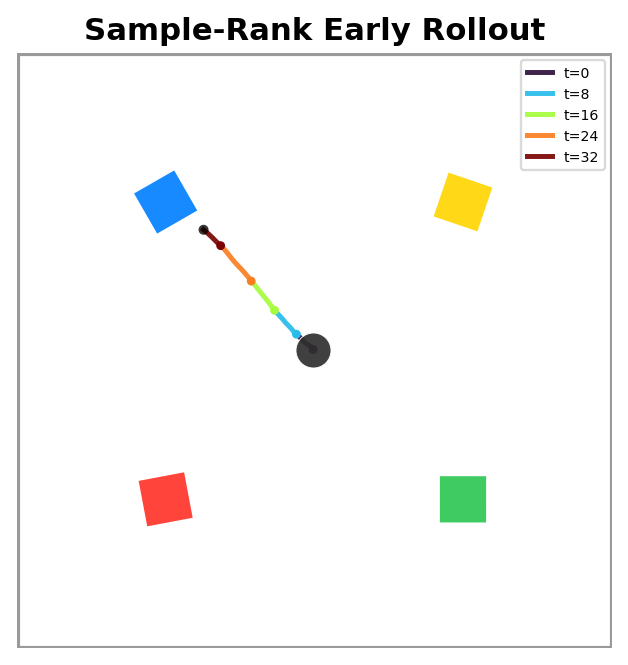

Saved sanity plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/sample_rank_prediction_sanity/20260429_163219/sample_rank_early_rollout.png


In [21]:
# Sanity check: sample-and-rank early rollout automaton predictions


import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils

try:
    from toy_squares.toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares.toy_squares_utils import _flip_y as _flip_toy_square_y
except ModuleNotFoundError:
    from toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares_utils import _flip_y as _flip_toy_square_y

def _format_onehot(values):
    return "[" + " ".join(f"{int(v):1d}" for v in values) + "]"


def _format_probs(values):
    return "[" + " ".join(f"{float(v):6.3f}" for v in values) + "]"


def _repeat_obs_batch(obs_tensor, n):
    if n == 1:
        return obs_tensor
    return {key: value.repeat((n,) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}


def _predict_future_label_probs(obs_tensor, action_chunk):
    state = _automaton_state_from_obs(obs_tensor).to(device=device, dtype=torch.float32)
    label = _automaton_label_from_state(state).to(device=device, dtype=torch.float32)
    action_flat = action_chunk.reshape(action_chunk.shape[0], -1).to(device=device, dtype=torch.float32)

    state_mean = torch.tensor(eval_stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(eval_stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(eval_stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(eval_stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        logits = automaton_model((state - state_mean) / state_std, (action_flat - action_mean) / action_std, label)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
    return probs


def _unnormalize_action_sequence(action_sequence):
    action_np = _to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np

    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {
        key: policy.action_normalization_stats[key]["offset"].shape[1:]
        for key in policy.action_normalization_stats
    }
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)


def _plot_chunk_colored_plain_rollout(ax, low_level_obs, setup_state, records):
    palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    blocks = _flip_toy_square_y(blocks)
    angles = -angles
    trajectory = np.stack([_latest_low_level_vector(obs["agent_pos"]) for obs in low_level_obs], axis=0)
    trajectory = _flip_toy_square_y(trajectory)

    cmap = plt.get_cmap("turbo")
    for chunk_idx, record in enumerate(records):
        start = int(record["t"])
        end = int(records[chunk_idx + 1]["t"]) if chunk_idx + 1 < len(records) else len(trajectory) - 1
        if end <= start:
            continue
        points = trajectory[start:end + 1]
        color = cmap(chunk_idx / max(1, len(records) - 1))
        ax.plot(points[:, 0], points[:, 1], color=color, linewidth=2.1, alpha=0.92, label=f"t={start}", zorder=2)
        ax.scatter(points[0, 0], points[0, 1], s=14, color=color, edgecolors="none", zorder=4)

    _draw_toy_square_blocks(ax, blocks, angles, palette, radius=0.11, alpha=0.95, zorder=4)
    start_agent = trajectory[0]
    ax.scatter([start_agent[0]], [start_agent[1]], s=220, marker="o", c="#2f2f2f", alpha=0.92, edgecolors="white", linewidths=0.4, zorder=5)
    ax.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=18, marker="o", c="#000000", alpha=0.78, edgecolors="none", zorder=6)
    ax.set_title("Sample-Rank Early Rollout", fontsize=13, fontweight="bold")
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=2.2, zorder=10)
    ax.add_patch(frame)
    if len(records) <= 12:
        ax.legend(loc="upper right", fontsize=6, frameon=True, framealpha=0.72, handlelength=1.8)


def run_sample_rank_early_prediction_sanity_check(horizon=200, target_label_idx=1, n_candidates=8):
    n_candidates = int(n_candidates)
    if n_candidates < 1:
        raise ValueError(f"n_candidates must be >= 1, got {n_candidates}.")
    setup_state = _to_numpy(early_decision_cube_setup(deterministic=True)).copy()
    obs = env.reset_to(setup_state)
    policy.start_episode()

    records = []
    action_queue = []
    total_reward = 0.0
    success = False
    steps = 0
    low_level_obs = [_obs_low_level_snapshot(obs)]

    for t in range(horizon):
        if not action_queue:
            current_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))
            obs_tensor = policy._prepare_observation(obs)
            obs_tensor_rank = _repeat_obs_batch(obs_tensor, n_candidates)
            with torch.no_grad():
                action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
            action_chunk = _unnormalize_action_sequence(action_chunk_n)
            action_chunk_tensor = torch.as_tensor(action_chunk, device=device, dtype=torch.float32)
            candidate_probs = _predict_future_label_probs(obs_tensor_rank, action_chunk_tensor)
            candidate_scores = candidate_probs[:, int(target_label_idx)]
            selected_idx = int(np.argmax(candidate_scores))
            pred_probs = candidate_probs[selected_idx].tolist()
            records.append({
                "t": t,
                "current_label": current_label["onehot"],
                "pred_probs": pred_probs,
                "selected_idx": selected_idx,
                "selected_score": float(candidate_scores[selected_idx]),
                "candidate_scores": candidate_scores.tolist(),
            })
            action_queue.extend(action_chunk[selected_idx])

        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, reward, done, info = env.step(action)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        total_reward += float(reward)
        steps = t + 1
        success = success or bool(info.get("success", False) or float(reward) > 0)
        if done or success:
            break

    final_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]

    print(
        f"Sample-rank early rollout finished: target={target_label_idx} ({LABEL_NAMES[int(target_label_idx)]}), "
        f"N={n_candidates}, success={success}, steps={steps:03d}, return={total_reward:6.3f}"
    )
    print(f"{'t':>4}  {'pick':>4}  {'score':>7}  {'current':>9}  {'pred_future_prob':>31}  {'final':>9}")
    for record in records:
        print(
            f"{record['t']:4d}  "
            f"{record['selected_idx']:4d}  "
            f"{record['selected_score']:7.3f}  "
            f"{_format_onehot(record['current_label']):>9}  "
            f"{_format_probs(record['pred_probs']):>31}  "
            f"{_format_onehot(final_label):>9}"
        )

    sanity_dir = OUTPUT_ROOT / "sample_rank_prediction_sanity" / datetime.now().strftime("%Y%m%d_%H%M%S")
    sanity_dir.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        sanity_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in low_level_obs]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in low_level_obs]),
    )
    np.save(sanity_dir / "setup_state.npy", setup_state)

    fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8), dpi=170, constrained_layout=True)
    _plot_chunk_colored_plain_rollout(ax, low_level_obs, setup_state, records)
    plot_path = sanity_dir / "sample_rank_early_rollout.png"
    fig.savefig(plot_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved sanity plot to {plot_path}")

    return records, final_label, plot_path

TARGET_RANK_LABEL_IDX = 1
SAMPLE_AND_RANK_N = 16
print("Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']")
print(f"Sample-and-rank target: {TARGET_RANK_LABEL_IDX} ({LABEL_NAMES[TARGET_RANK_LABEL_IDX]}), N={SAMPLE_AND_RANK_N}")

plain_prediction_records, plain_prediction_final_label, plain_prediction_plot_path = run_sample_rank_early_prediction_sanity_check(
    target_label_idx=TARGET_RANK_LABEL_IDX,
    n_candidates=SAMPLE_AND_RANK_N,
)

Summary:

1. Early Guidance: 
- Works perfectly for ALL blocks

2. Late Guidance:
- Perfect for outer blocks (blue, yellow)
- harder to guide to inner blocks (red, yellow maybe 10 - 30%), because the outer blocks are in the way ... 

Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']
Chain target: [1, 2, 0, 1, 3, 0] (['at_blue', 'at_red', 'at_green', 'at_blue', 'at_yellow', 'at_green']), N=8
Chain rollout finished: complete=True, stages=6/6, steps=387, return=54.000
Reached: ['at_blue', 'at_red', 'at_green', 'at_blue', 'at_yellow', 'at_green']
   t  stage     target  pick    score    current                 pred_future_prob      final
   0      0    at_blue     4    0.989  [0 0 0 0]    [ 0.000  0.989  0.001  0.001]  [1 0 0 0]
   8      0    at_blue     4    0.997  [0 0 0 0]    [ 0.000  0.997  0.000  0.000]  [1 0 0 0]
  16      0    at_blue     4    0.999  [0 0 0 0]    [ 0.000  0.999  0.000  0.000]  [1 0 0 0]
  24      0    at_blue     0    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [1 0 0 0]
  32      0    at_blue     7    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [1 0 0 0]
  40      0    at_blue     7    1.000  [0 0 0 0]    [ 0.000  1.000  0.000  0.000]  [1 0 0 0]
  41      1     at_red  

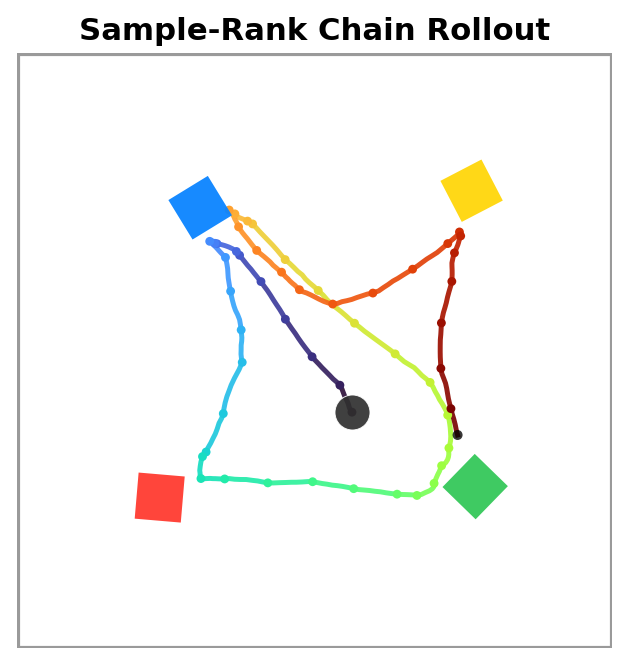

Image(value=b'GIF89a\x80\x00\x80\x00\x84\x00\x00\xff\xff\xff\xff\xff\xbf\xff\xff\x80\xff\xff@\xff\xff\x00\xbf\…

Saved chain plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/sample_rank_chain_sanity/chain_1-2-0-1-3-0_n8_20260429_161540/sample_rank_chain_rollout.png
Saved chain GIF to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/sample_rank_chain_sanity/chain_1-2-0-1-3-0_n8_20260429_161540/sample_rank_chain_rollout.gif


In [10]:
# Sanity check: sample-and-rank toward an ordered chain of labels


import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils

try:
    from toy_squares.toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares.toy_squares_utils import _flip_y as _flip_toy_square_y
except ModuleNotFoundError:
    from toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares_utils import _flip_y as _flip_toy_square_y


def _chain_repeat_obs_batch(obs_tensor, n):
    if n == 1:
        return obs_tensor
    return {key: value.repeat((n,) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}


def _chain_predict_future_label_probs(obs_tensor, action_chunk):
    state = _automaton_state_from_obs(obs_tensor).to(device=device, dtype=torch.float32)
    label = _automaton_label_from_state(state).to(device=device, dtype=torch.float32)
    action_flat = action_chunk.reshape(action_chunk.shape[0], -1).to(device=device, dtype=torch.float32)

    state_mean = torch.tensor(eval_stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(eval_stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(eval_stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(eval_stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        logits = automaton_model((state - state_mean) / state_std, (action_flat - action_mean) / action_std, label)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
    return probs


def _chain_unnormalize_action_sequence(action_sequence):
    action_np = _to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np

    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {
        key: policy.action_normalization_stats[key]["offset"].shape[1:]
        for key in policy.action_normalization_stats
    }
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)


def _chain_format_onehot(values):
    return "[" + " ".join(f"{int(v):1d}" for v in values) + "]"


def _chain_format_probs(values):
    return "[" + " ".join(f"{float(v):6.3f}" for v in values) + "]"


def _plot_chunk_colored_chain_rollout(ax, low_level_obs, setup_state, records):
    palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    blocks = _flip_toy_square_y(blocks)
    angles = -angles
    trajectory = np.stack([_latest_low_level_vector(obs["agent_pos"]) for obs in low_level_obs], axis=0)
    trajectory = _flip_toy_square_y(trajectory)

    cmap = plt.get_cmap("turbo")
    for chunk_idx, record in enumerate(records):
        start = int(record["t"])
        end = int(records[chunk_idx + 1]["t"]) if chunk_idx + 1 < len(records) else len(trajectory) - 1
        if end <= start:
            continue
        points = trajectory[start:end + 1]
        color = cmap(chunk_idx / max(1, len(records) - 1))
        target_name = LABEL_NAMES[int(record["target_label_idx"])]
        ax.plot(points[:, 0], points[:, 1], color=color, linewidth=2.1, alpha=0.92, label=f"t={start} {target_name}", zorder=2)
        ax.scatter(points[0, 0], points[0, 1], s=14, color=color, edgecolors="none", zorder=4)

    _draw_toy_square_blocks(ax, blocks, angles, palette, radius=0.11, alpha=0.95, zorder=4)
    start_agent = trajectory[0]
    ax.scatter([start_agent[0]], [start_agent[1]], s=220, marker="o", c="#2f2f2f", alpha=0.92, edgecolors="white", linewidths=0.4, zorder=5)
    ax.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=18, marker="o", c="#000000", alpha=0.78, edgecolors="none", zorder=6)
    ax.set_title("Sample-Rank Chain Rollout", fontsize=13, fontweight="bold")
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=2.2, zorder=10)
    ax.add_patch(frame)
    if len(records) <= 12:
        ax.legend(loc="upper right", fontsize=5.5, frameon=True, framealpha=0.72, handlelength=1.8)


def run_sample_rank_chain_sanity_check(label_chain, n_candidates=8, horizon=200, deterministic_setup=True):
    label_chain = [int(idx) for idx in label_chain]
    n_candidates = int(n_candidates)
    if not label_chain:
        raise ValueError("label_chain must contain at least one label index.")
    if n_candidates < 1:
        raise ValueError(f"n_candidates must be >= 1, got {n_candidates}.")

    setup_state = _to_numpy(early_decision_cube_setup(deterministic=deterministic_setup)).copy()
    obs = env.reset_to(setup_state)
    policy.start_episode()

    records = []
    reaches = []
    action_queue = []
    total_reward = 0.0
    steps = 0
    chain_pos = 0
    low_level_obs = [_obs_low_level_snapshot(obs)]
    frames = [_render_frame(env)]

    for t in range(horizon):
        if not action_queue:
            target_label_idx = label_chain[chain_pos]
            current_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))
            obs_tensor = policy._prepare_observation(obs)
            obs_tensor_rank = _chain_repeat_obs_batch(obs_tensor, n_candidates)
            with torch.no_grad():
                action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
            action_chunk = _chain_unnormalize_action_sequence(action_chunk_n)
            action_chunk_tensor = torch.as_tensor(action_chunk, device=device, dtype=torch.float32)
            candidate_probs = _chain_predict_future_label_probs(obs_tensor_rank, action_chunk_tensor)
            candidate_scores = candidate_probs[:, target_label_idx]
            selected_idx = int(np.argmax(candidate_scores))
            pred_probs = candidate_probs[selected_idx].tolist()
            records.append({
                "t": t,
                "stage": chain_pos,
                "target_label_idx": target_label_idx,
                "current_label": current_label["onehot"],
                "pred_probs": pred_probs,
                "selected_idx": selected_idx,
                "selected_score": float(candidate_scores[selected_idx]),
                "candidate_scores": candidate_scores.tolist(),
            })
            action_queue.extend(action_chunk[selected_idx])

        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, reward, done, info = env.step(action)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        frames.append(_render_frame(env))
        total_reward += float(reward)
        steps = t + 1

        current_onehot = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
        if chain_pos < len(label_chain) and int(current_onehot[label_chain[chain_pos]]) == 1:
            reaches.append({"t": steps, "stage": chain_pos, "label_idx": label_chain[chain_pos], "label_name": LABEL_NAMES[label_chain[chain_pos]]})
            chain_pos += 1
            action_queue.clear()
            if chain_pos >= len(label_chain):
                break

    final_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
    complete = chain_pos >= len(label_chain)
    chain_names = [LABEL_NAMES[idx] for idx in label_chain]
    reached_names = [item["label_name"] for item in reaches]

    print(f"Chain target: {label_chain} ({chain_names}), N={n_candidates}")
    print(f"Chain rollout finished: complete={complete}, stages={chain_pos}/{len(label_chain)}, steps={steps:03d}, return={total_reward:6.3f}")
    print(f"Reached: {reached_names}")
    print(f"{'t':>4}  {'stage':>5}  {'target':>9}  {'pick':>4}  {'score':>7}  {'current':>9}  {'pred_future_prob':>31}  {'final':>9}")
    for record in records:
        target_name = LABEL_NAMES[int(record["target_label_idx"])]
        print(
            f"{record['t']:4d}  "
            f"{record['stage']:5d}  "
            f"{target_name:>9}  "
            f"{record['selected_idx']:4d}  "
            f"{record['selected_score']:7.3f}  "
            f"{_chain_format_onehot(record['current_label']):>9}  "
            f"{_chain_format_probs(record['pred_probs']):>31}  "
            f"{_chain_format_onehot(final_label):>9}"
        )

    chain_tag = "-".join(str(idx) for idx in label_chain)
    sanity_dir = OUTPUT_ROOT / "sample_rank_chain_sanity" / f"chain_{chain_tag}_n{n_candidates}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    sanity_dir.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        sanity_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in low_level_obs]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in low_level_obs]),
    )
    np.save(sanity_dir / "setup_state.npy", setup_state)
    with open(sanity_dir / "chain_summary.json", "w", encoding="utf-8") as f:
        json.dump({
            "label_chain": label_chain,
            "chain_names": chain_names,
            "n_candidates": n_candidates,
            "complete": complete,
            "steps": steps,
            "return": total_reward,
            "reaches": reaches,
            "records": records,
        }, f, indent=2)

    fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8), dpi=170, constrained_layout=True)
    _plot_chunk_colored_chain_rollout(ax, low_level_obs, setup_state, records)
    plot_path = sanity_dir / "sample_rank_chain_rollout.png"
    fig.savefig(plot_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    gif_path = sanity_dir / "sample_rank_chain_rollout.gif"
    imageio.mimsave(gif_path, frames, duration=0.12)
    display(widgets.Image(value=gif_path.read_bytes(), format="gif", layout=widgets.Layout(width="260px")))
    print(f"Saved chain plot to {plot_path}")
    print(f"Saved chain GIF to {gif_path}")

    return records, reaches, complete, plot_path, gif_path

CHAIN_LABEL_IDXS = [1, 2, 0, 1, 3, 0]  # at_blue -> at_red -> at_green -> at_blue -> at_yellow -> at_green
CHAIN_SAMPLE_AND_RANK_N = 8
CHAIN_HORIZON = 400
CHAIN_DETERMINISTIC_SETUP = False 

print("Label order: ['at_green', 'at_blue', 'at_red', 'at_yellow']")
chain_records, chain_reaches, chain_complete, chain_plot_path, chain_gif_path = run_sample_rank_chain_sanity_check(
    label_chain=CHAIN_LABEL_IDXS,
    n_candidates=CHAIN_SAMPLE_AND_RANK_N,
    horizon=CHAIN_HORIZON,
    deterministic_setup=CHAIN_DETERMINISTIC_SETUP,
)

### Gradient Denoising Guidance Troublshooting

#### Using Post sampling guidance 

In [74]:
# Single 8-action diagnostic: unguided vs gradient-guided chunk


try:
    from toy_squares.toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares.toy_squares_utils import _flip_y as _flip_toy_square_y
except ModuleNotFoundError:
    from toy_squares_utils import _draw_blocks as _draw_toy_square_blocks
    from toy_squares_utils import _flip_y as _flip_toy_square_y


def _single_format_onehot(values):
    return "[" + " ".join(f"{int(v):1d}" for v in values) + "]"


def _single_format_probs(values):
    return "[" + " ".join(f"{float(v):6.3f}" for v in values) + "]"


def _torch_action_normalization_parts(dtype=torch.float32):
    if policy.action_normalization_stats is None:
        return None

    action_keys = policy.policy.global_config.train.action_keys
    offsets = []
    scales = []
    for key in action_keys:
        offset = torch.as_tensor(policy.action_normalization_stats[key]["offset"].reshape(-1), device=device, dtype=dtype)
        scale = torch.as_tensor(policy.action_normalization_stats[key]["scale"].reshape(-1), device=device, dtype=dtype)
        offsets.append(offset)
        scales.append(scale)
    return torch.cat(offsets, dim=0), torch.cat(scales, dim=0)


def _unnormalize_action_sequence_torch(action_sequence):
    parts = _torch_action_normalization_parts(dtype=action_sequence.dtype)
    if parts is None:
        return action_sequence
    offset, scale = parts
    offset = offset.to(device=action_sequence.device, dtype=action_sequence.dtype)
    scale = scale.to(device=action_sequence.device, dtype=action_sequence.dtype)
    return action_sequence * scale.view(1, 1, -1) + offset.view(1, 1, -1)


def _single_score_action_chunk(obs_tensor, raw_action_chunk):
    state = _automaton_state_from_obs(obs_tensor).to(device=device, dtype=torch.float32)
    label = _automaton_label_from_state(state).to(device=device, dtype=torch.float32)
    action_flat = raw_action_chunk.reshape(raw_action_chunk.shape[0], -1).to(device=device, dtype=torch.float32)

    state_mean = torch.tensor(eval_stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(eval_stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(eval_stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(eval_stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)

    with torch.no_grad():
        logits = automaton_model((state - state_mean) / state_std, (action_flat - action_mean) / action_std, label)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
    return probs


def make_single_chunk_raw_action_guidance_fn(target_label_idx):
    state_mean = torch.tensor(eval_stats["states_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(eval_stats["states_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(eval_stats["actions_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(eval_stats["actions_std"], device=device, dtype=torch.float32).unsqueeze(0)
    start = int(policy.policy.algo_config.horizon.observation_horizon) - 1
    action_horizon = int(policy.policy.algo_config.horizon.action_horizon)
    end = start + action_horizon

    def guidance_function(obs_dict, actions):
        state = _automaton_state_from_obs(obs_dict).to(device=actions.device, dtype=actions.dtype)
        label = _automaton_label_from_state(state).to(device=actions.device, dtype=actions.dtype)
        action_chunk_n = actions[:, start:end, :]
        action_chunk_raw = _unnormalize_action_sequence_torch(action_chunk_n)
        action_flat = action_chunk_raw.reshape(action_chunk_raw.shape[0], -1)
        logits = automaton_model(
            (state - state_mean.to(device=actions.device, dtype=actions.dtype)) / state_std.to(device=actions.device, dtype=actions.dtype),
            (action_flat - action_mean.to(device=actions.device, dtype=actions.dtype)) / action_std.to(device=actions.device, dtype=actions.dtype),
            label,
        )
        objective = logits[:, int(target_label_idx)].mean()
        return torch.autograd.grad(objective, actions, retain_graph=False, create_graph=False)[0]

    return guidance_function


def _single_execute_chunk(setup_state, action_chunk_raw):
    obs = env.reset_to(setup_state)
    low_level_obs = [_obs_low_level_snapshot(obs)]
    total_reward = 0.0
    done = False
    info = {}
    for action in np.asarray(action_chunk_raw[0], dtype=np.float32):
        obs, reward, done, info = env.step(action)
        total_reward += float(reward)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        if done:
            break
    final_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
    return {
        "low_level_obs": low_level_obs,
        "final_label": final_label,
        "return": total_reward,
        "done": bool(done),
        "info": info,
    }


def _single_trajectory_from_low_level(low_level_obs):
    trajectory = np.stack([_latest_low_level_vector(obs["agent_pos"]) for obs in low_level_obs], axis=0)
    return _flip_toy_square_y(trajectory)



In [60]:
# Concise score-only sweep: does diffusion guidance improve the automaton target score?

SWEEP_TARGET_LABEL_IDX = 2  # at_red
SWEEP_ENV_SEED = 1
SWEEP_ROLLOUT_SEED = 4
SWEEP_DETERMINISTIC_SETUP = False
SWEEP_GUIDANCE_SCALES = [0.0, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03]


def run_guidance_score_sweep():
    old_debug = getattr(policy.policy, "debug_guidance_actions", False)
    policy.policy.debug_guidance_actions = False

    reseed(SWEEP_ENV_SEED)
    setup_state = _to_numpy(early_decision_cube_setup(deterministic=SWEEP_DETERMINISTIC_SETUP)).copy()
    obs0 = env.reset_to(setup_state)
    obs_tensor = policy._prepare_observation(obs0)
    guidance_fn = make_single_chunk_raw_action_guidance_fn(SWEEP_TARGET_LABEL_IDX)

    rows = []
    baseline_raw = None
    for scale in SWEEP_GUIDANCE_SCALES:
        reseed(SWEEP_ROLLOUT_SEED)
        policy.start_episode()
        if float(scale) == 0.0:
            with torch.no_grad():
                chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor)
        else:
            chunk_n = policy.policy._get_action_trajectory_guidance(
                obs_dict=obs_tensor,
                guidance_function=guidance_fn,
                guidance_scale=float(scale),
            )
        chunk_raw = _unnormalize_action_sequence_torch(chunk_n).detach()
        probs = _single_score_action_chunk(obs_tensor, chunk_raw)[0]
        if baseline_raw is None:
            baseline_raw = chunk_raw.clone()
            baseline_score = float(probs[int(SWEEP_TARGET_LABEL_IDX)])
        delta_action = float((chunk_raw - baseline_raw).abs().max().detach().cpu())
        rows.append((float(scale), probs, float(probs[int(SWEEP_TARGET_LABEL_IDX)]), delta_action))

    print(f"Target idx {SWEEP_TARGET_LABEL_IDX} ({LABEL_NAMES[int(SWEEP_TARGET_LABEL_IDX)]})")
    print(f"Env seed={SWEEP_ENV_SEED}, rollout seed={SWEEP_ROLLOUT_SEED}")
    print(f"{'scale':>9}  {'target':>8}  {'delta':>8}  {'max|da|':>9}  {'argmax':>8}  {'pred_future_prob':>31}")
    for scale, probs, score, delta_action in rows:
        argmax_idx = int(np.argmax(probs))
        print(
            f"{scale:9.4g}  "
            f"{score:8.3f}  "
            f"{score - baseline_score:8.3f}  "
            f"{delta_action:9.4f}  "
            f"{argmax_idx:>8d}  "
            f"{_single_format_probs(probs):>31}"
        )

    policy.policy.debug_guidance_actions = old_debug
    return rows


guidance_score_sweep_rows = run_guidance_score_sweep()


Target idx 2 (at_red)
Env seed=1, rollout seed=4
    scale    target     delta    max|da|    argmax                 pred_future_prob
        0     0.237     0.000     0.0000         3    [ 0.062  0.296  0.237  0.374]
   0.0001     0.237    -0.000     0.0000         3    [ 0.062  0.296  0.237  0.374]
   0.0003     0.236    -0.001     0.0001         3    [ 0.062  0.296  0.236  0.374]
    0.001     0.235    -0.002     0.0003         3    [ 0.062  0.296  0.235  0.376]
    0.003     0.235    -0.002     0.0008         3    [ 0.062  0.296  0.235  0.377]
     0.01     0.255     0.018     0.0014         3    [ 0.070  0.295  0.255  0.350]
     0.03     0.325     0.088     0.0092         2    [ 0.100  0.283  0.325  0.262]


In [89]:
# Isolation test: direct gradient ascent on the sampled 8-action chunk.
# If this increases target score, the automaton gradient is usable and DDPM injection is the suspect.

DIRECT_TARGET_LABEL_IDX = 0  # at_blue
DIRECT_ENV_SEED = 1
DIRECT_ROLLOUT_SEED = 4
DIRECT_STEPS = 10
DIRECT_STEP_SIZES = [0.0, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]


def _direct_chunk_probs(obs_tensor, chunk_n):
    chunk_raw = _unnormalize_action_sequence_torch(chunk_n)
    return _single_score_action_chunk(obs_tensor, chunk_raw)[0]


def _direct_chunk_grad(obs_tensor, chunk_n, target_idx):
    state = _automaton_state_from_obs(obs_tensor).to(device=chunk_n.device, dtype=chunk_n.dtype)
    label = _automaton_label_from_state(state).to(device=chunk_n.device, dtype=chunk_n.dtype)
    chunk_raw = _unnormalize_action_sequence_torch(chunk_n)
    action_flat = chunk_raw.reshape(chunk_raw.shape[0], -1)
    state_mean = torch.tensor(eval_stats["states_mean"], device=chunk_n.device, dtype=chunk_n.dtype).unsqueeze(0)
    state_std = torch.tensor(eval_stats["states_std"], device=chunk_n.device, dtype=chunk_n.dtype).unsqueeze(0)
    action_mean = torch.tensor(eval_stats["actions_mean"], device=chunk_n.device, dtype=chunk_n.dtype).unsqueeze(0)
    action_std = torch.tensor(eval_stats["actions_std"], device=chunk_n.device, dtype=chunk_n.dtype).unsqueeze(0)
    logits = automaton_model((state - state_mean) / state_std, (action_flat - action_mean) / action_std, label)
    objective = logits[:, int(target_idx)].mean()
    return torch.autograd.grad(objective, chunk_n, retain_graph=False, create_graph=False)[0]


def run_direct_chunk_gradient_sweep():
    old_debug = getattr(policy.policy, "debug_guidance_actions", False)
    policy.policy.debug_guidance_actions = False
    reseed(DIRECT_ENV_SEED)
    setup_state = _to_numpy(early_decision_cube_setup(deterministic=False)).copy()
    obs0 = env.reset_to(setup_state)
    obs_tensor = policy._prepare_observation(obs0)

    reseed(DIRECT_ROLLOUT_SEED)
    policy.start_episode()
    with torch.no_grad():
        base_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor).detach()
    base_probs = _direct_chunk_probs(obs_tensor, base_chunk_n)
    base_score = float(base_probs[int(DIRECT_TARGET_LABEL_IDX)])

    rows = []
    for step_size in DIRECT_STEP_SIZES:
        chunk_n = base_chunk_n.clone()
        for _ in range(int(DIRECT_STEPS)):
            x = chunk_n.detach().requires_grad_(True)
            grad = _direct_chunk_grad(obs_tensor, x, DIRECT_TARGET_LABEL_IDX)
            chunk_n = torch.clamp(x + float(step_size) * grad.detach(), -1.0, 1.0).detach()
        probs = _direct_chunk_probs(obs_tensor, chunk_n)
        score = float(probs[int(DIRECT_TARGET_LABEL_IDX)])
        max_da = float((chunk_n - base_chunk_n).abs().max().detach().cpu())
        rows.append((float(step_size), probs, score, max_da))

    print(f"Direct chunk ascent target idx {DIRECT_TARGET_LABEL_IDX} ({LABEL_NAMES[int(DIRECT_TARGET_LABEL_IDX)]}), steps={DIRECT_STEPS}")
    print(f"Env seed={DIRECT_ENV_SEED}, rollout seed={DIRECT_ROLLOUT_SEED}")
    print(f"{'step':>9}  {'target':>8}  {'delta':>8}  {'max|da|':>9}  {'argmax':>8}  {'pred_future_prob':>31}")
    for step_size, probs, score, max_da in rows:
        print(
            f"{step_size:9.1e}  "
            f"{score:8.3f}  "
            f"{score - base_score:8.3f}  "
            f"{max_da:9.4f}  "
            f"{int(np.argmax(probs)):8d}  "
            f"{_single_format_probs(probs):>31}"
        )

    policy.policy.debug_guidance_actions = old_debug
    return rows


direct_chunk_gradient_rows = run_direct_chunk_gradient_sweep()


Direct chunk ascent target idx 0 (at_green), steps=10
Env seed=1, rollout seed=4
     step    target     delta    max|da|    argmax                 pred_future_prob
  0.0e+00     0.062     0.000     0.0000         3    [ 0.062  0.296  0.237  0.374]
  1.0e-05     0.089     0.026     0.0035         3    [ 0.089  0.267  0.276  0.359]
  3.0e-05     0.197     0.135     0.0110         2    [ 0.197  0.194  0.352  0.298]
  1.0e-04     0.997     0.935     0.0456         0    [ 0.997  0.000  0.003  0.000]
  3.0e-04     0.999     0.937     0.0598         0    [ 0.999  0.000  0.001  0.000]
  1.0e-03     0.999     0.937     0.0539         0    [ 0.999  0.000  0.001  0.000]
  3.0e-03     0.994     0.932     0.0849         0    [ 0.994  0.000  0.002  0.000]


Post-sample target: 2 (at_red)
Env seed=1, rollout seed=4, step_size=0.0003
steps    target    max|da|   mean|da|    clamp          final                 pred_future_prob
    0         0.237     0.0000     0.0000    0.000      [0 0 0 0]    [ 0.062  0.296  0.237  0.374]  
    1         0.311     0.0067     0.0019    0.000      [0 0 0 0]    [ 0.113  0.255  0.311  0.318]  
    3         0.424     0.0176     0.0046    0.000      [0 0 0 0]    [ 0.249  0.178  0.424  0.206]  
    5         0.498     0.0252     0.0072    0.000      [0 0 0 0]    [ 0.338  0.136  0.498  0.140]  
   10         0.736     0.0390     0.0149    0.000      [0 0 0 0]    [ 0.160  0.081  0.736  0.052]  
   20         0.996     0.0889     0.0331    0.000      [0 0 0 0]    [ 0.000  0.001  0.996  0.000]  


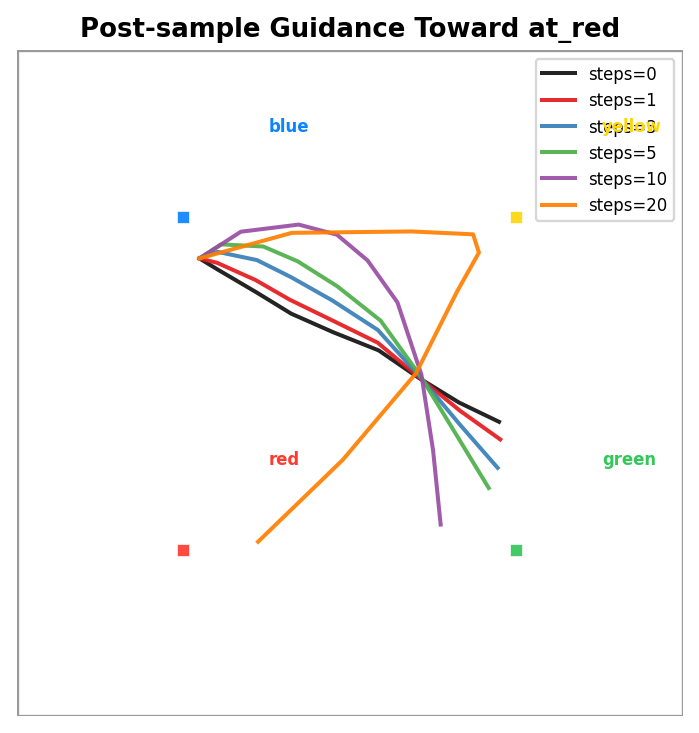

In [83]:
# Execute a sweep of post-sample guided chunks with different gradient-ascent step counts.

POST_TARGET_LABEL_IDX = 2  # at_blue
POST_ENV_SEED = 1
POST_ROLLOUT_SEED = 4
POST_STEP_SIZE = 3e-4
POST_STEP_COUNTS = [0, 1, 3, 5, 10, 20]
POST_DETERMINISTIC_SETUP = False


def optimize_chunk_post_sample(obs_tensor, base_chunk_n, target_idx, step_size, steps):
    chunk_n = base_chunk_n.detach().clone()
    for _ in range(int(steps)):
        x = chunk_n.detach().requires_grad_(True)
        grad = _direct_chunk_grad(obs_tensor, x, target_idx)
        chunk_n = torch.clamp(x + float(step_size) * grad.detach(), -1.0, 1.0).detach()
    return chunk_n


def _plot_post_sample_step_sweep(setup_state, run_rows, target_label_idx):
    block_palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    blocks = _flip_toy_square_y(blocks)
    trajectories = [
        _single_trajectory_from_low_level(row["result"]["low_level_obs"])
        for row in run_rows
    ]
    traj_points = np.concatenate(trajectories, axis=0)
    target_block = blocks[[LABEL_TO_STATE_BLOCK_IDX[int(target_label_idx)]]]
    traj_center = traj_points.mean(axis=0)
    target_dist = np.linalg.norm(target_block[0] - traj_center)
    include_target = target_dist < 0.32
    all_points = np.concatenate([traj_points, target_block], axis=0) if include_target else traj_points
    pad = 0.035
    x_min, y_min = np.maximum(all_points.min(axis=0) - pad, -1.0)
    x_max, y_max = np.minimum(all_points.max(axis=0) + pad, 1.0)
    if x_max - x_min < 0.14:
        mid = 0.5 * (x_min + x_max)
        x_min, x_max = max(-1.0, mid - 0.07), min(1.0, mid + 0.07)
    if y_max - y_min < 0.14:
        mid = 0.5 * (y_min + y_max)
        y_min, y_max = max(-1.0, mid - 0.07), min(1.0, mid + 0.07)

    fig, ax = plt.subplots(1, 1, figsize=(4.2, 4.2), dpi=170, constrained_layout=True)
    line_colors = ["#111111", "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#f781bf"]
    for row, traj, color in zip(run_rows, trajectories, line_colors):
        ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=1.7, alpha=0.92, label=f"steps={row['steps']}", zorder=3)

    for block_idx, (xy, color) in enumerate(zip(blocks, block_palette)):
        x = float(np.clip(xy[0], x_min + 0.035, x_max - 0.035))
        y = float(np.clip(xy[1], y_min + 0.035, y_max - 0.035))
        ax.scatter([x], [y], s=26, marker="s", color=color, alpha=0.92, edgecolors="white", linewidths=0.3, zorder=5)
        ax.text(x + 0.018, y + 0.018, STATE_BLOCK_NAMES[block_idx], color=color, fontsize=7, weight="bold", zorder=6)

    ax.set_title(f"Post-sample Guidance Toward {LABEL_NAMES[int(target_label_idx)]}", fontsize=11, fontweight="bold")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.legend(loc="upper right", fontsize=7, frameon=True, framealpha=0.78, handlelength=2.0)
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=1.4, zorder=10)
    ax.add_patch(frame)
    return fig


def run_post_sample_guided_chunk_execution():
    old_debug = getattr(policy.policy, "debug_guidance_actions", False)
    policy.policy.debug_guidance_actions = False

    reseed(POST_ENV_SEED)
    setup_state = _to_numpy(early_decision_cube_setup(deterministic=POST_DETERMINISTIC_SETUP)).copy()
    obs0 = env.reset_to(setup_state)
    obs_tensor = policy._prepare_observation(obs0)

    reseed(POST_ROLLOUT_SEED)
    policy.start_episode()
    with torch.no_grad():
        unguided_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor).detach()
    run_rows = []
    for steps in POST_STEP_COUNTS:
        chunk_n = optimize_chunk_post_sample(obs_tensor, unguided_chunk_n, POST_TARGET_LABEL_IDX, POST_STEP_SIZE, steps)
        chunk_raw = _unnormalize_action_sequence_torch(chunk_n).detach()
        probs = _single_score_action_chunk(obs_tensor, chunk_raw)[0]
        result = _single_execute_chunk(setup_state, chunk_raw.detach().cpu().numpy())
        delta = chunk_n - unguided_chunk_n
        run_rows.append({
            "steps": int(steps),
            "chunk_n": chunk_n,
            "probs": probs,
            "result": result,
            "max_da": float(delta.abs().max().detach().cpu()),
            "mean_da": float(delta.abs().mean().detach().cpu()),
            "clamp_frac": float(((chunk_n.abs() >= 0.999).float().mean()).detach().cpu()),
        })

    print(f"Post-sample target: {POST_TARGET_LABEL_IDX} ({LABEL_NAMES[int(POST_TARGET_LABEL_IDX)]})")
    print(f"Env seed={POST_ENV_SEED}, rollout seed={POST_ROLLOUT_SEED}, step_size={POST_STEP_SIZE:g}")
    print(f"{'steps':>5}  {'target':>8}  {'max|da|':>9}  {'mean|da|':>9}  {'clamp':>7}  {'final':>13}  {'pred_future_prob':>31}")
    for row in run_rows:
        probs = row["probs"]
        result = row["result"]
        print(
            f"{row['steps']:5d}  "
            f"{float(probs[int(POST_TARGET_LABEL_IDX)]):12.3f}  "
            f"{row['max_da']:9.4f}  "
            f"{row['mean_da']:9.4f}  "
            f"{row['clamp_frac']:7.3f}  "
            f"{_single_format_onehot(result['final_label']):>13}  "
            f"{_single_format_probs(probs):>31}  "
        )

    fig = _plot_post_sample_step_sweep(setup_state, run_rows, POST_TARGET_LABEL_IDX)
    display(fig)
    plt.close(fig)
    policy.policy.debug_guidance_actions = old_debug
    return {
        "setup_state": setup_state,
        "base_chunk_n": unguided_chunk_n,
        "rows": run_rows,
    }


post_sample_guided_chunk_result = run_post_sample_guided_chunk_execution()


Post-sample full rollout: target=0 (at_green), steps_per_chunk=20, step_size=0.0003, success=True, steps=078, return= 1.000
   t    score    max|da|    clamp    current                 pred_future_prob      final
   0    0.693     0.0547    0.000  [0 0 0 0]    [ 0.693  0.007  0.004  0.422]  [0 0 0 1]
   8    0.678     0.0495    0.000  [0 0 0 0]    [ 0.678  0.008  0.006  0.501]  [0 0 0 1]
  16    0.606     0.0323    0.000  [0 0 0 0]    [ 0.606  0.006  0.009  0.524]  [0 0 0 1]
  24    0.540     0.0267    0.000  [0 0 0 0]    [ 0.540  0.005  0.012  0.462]  [0 0 0 1]
  32    0.453     0.0111    0.000  [0 0 0 0]    [ 0.453  0.004  0.012  0.354]  [0 0 0 1]
  40    0.352     0.0038    0.000  [0 0 0 0]    [ 0.352  0.003  0.012  0.339]  [0 0 0 1]
  48    0.304     0.0171    0.000  [0 0 0 0]    [ 0.304  0.004  0.011  0.359]  [0 0 0 1]
  56    0.301     0.0192    0.000  [0 0 0 0]    [ 0.301  0.004  0.010  0.353]  [0 0 0 1]
  64    0.369     0.0094    0.000  [0 0 0 0]    [ 0.369  0.007  0.019  0.25

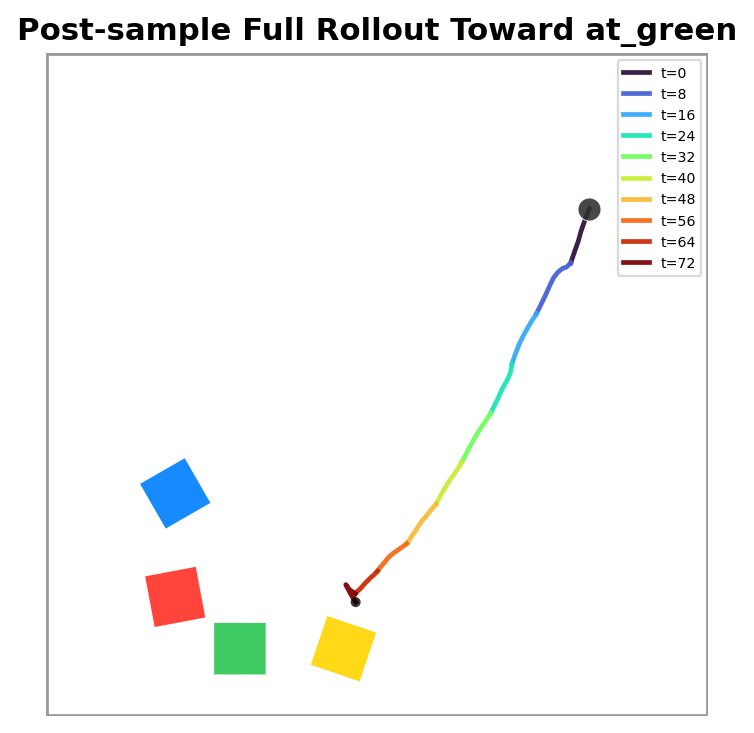

In [111]:
# Full rollout with post-sample guidance: replan every 8 actions and color each chunk.


def _plot_post_sample_full_rollout_chunks(ax, low_level_obs, setup_state, records, target_label_idx):
    palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    blocks = _flip_toy_square_y(blocks)
    angles = -angles
    trajectory = np.stack([_latest_low_level_vector(obs["agent_pos"]) for obs in low_level_obs], axis=0)
    trajectory = _flip_toy_square_y(trajectory)
    cmap = plt.get_cmap("turbo")

    for chunk_idx, record in enumerate(records):
        start = int(record["t"])
        end = int(records[chunk_idx + 1]["t"]) if chunk_idx + 1 < len(records) else len(trajectory) - 1
        if end <= start:
            continue
        points = trajectory[start:end + 1]
        color = cmap(chunk_idx / max(1, len(records) - 1))
        ax.plot(points[:, 0], points[:, 1], color=color, linewidth=2.0, alpha=0.94, label=f"t={start}", zorder=2)

    _draw_toy_square_blocks(ax, blocks, angles, palette, radius=0.11, alpha=0.95, zorder=4)
    ax.scatter([trajectory[0, 0]], [trajectory[0, 1]], s=95, marker="o", c="#2f2f2f", alpha=0.88, edgecolors="white", linewidths=0.4, zorder=5)
    ax.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=18, marker="o", c="#000000", alpha=0.78, edgecolors="none", zorder=6)
    ax.set_title(f"Post-sample Full Rollout Toward {LABEL_NAMES[int(target_label_idx)]}", fontsize=13, fontweight="bold")
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=2.0, zorder=10)
    ax.add_patch(frame)
    if len(records) <= 16:
        ax.legend(loc="upper right", fontsize=6, frameon=True, framealpha=0.72, handlelength=1.8)


def run_post_sample_guided_full_rollout():
    old_debug = getattr(policy.policy, "debug_guidance_actions", False)
    policy.policy.debug_guidance_actions = False

    reseed(FULL_POST_ENV_SEED)
    setup_state = _to_numpy(late_decision_cube_setup(deterministic=FULL_POST_DETERMINISTIC_SETUP)).copy()
    reseed(FULL_POST_ROLLOUT_SEED)
    obs = env.reset_to(setup_state)
    policy.start_episode()

    records = []
    action_queue = []
    low_level_obs = [_obs_low_level_snapshot(obs)]
    total_reward = 0.0
    success = False
    steps = 0

    for t in range(int(FULL_POST_HORIZON)):
        if not action_queue:
            current_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))
            obs_tensor = policy._prepare_observation(obs)
            with torch.no_grad():
                base_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor).detach()
            guided_chunk_n = optimize_chunk_post_sample(
                obs_tensor,
                base_chunk_n,
                FULL_POST_TARGET_LABEL_IDX,
                FULL_POST_STEP_SIZE,
                FULL_POST_GUIDANCE_STEPS,
            )
            guided_chunk_raw = _unnormalize_action_sequence_torch(guided_chunk_n).detach()
            probs = _single_score_action_chunk(obs_tensor, guided_chunk_raw)[0]
            delta = guided_chunk_n - base_chunk_n
            records.append({
                "t": t,
                "current_label": current_label["onehot"],
                "pred_probs": probs.tolist(),
                "target_score": float(probs[int(FULL_POST_TARGET_LABEL_IDX)]),
                "max_da": float(delta.abs().max().detach().cpu()),
                "mean_da": float(delta.abs().mean().detach().cpu()),
                "clamp_frac": float(((guided_chunk_n.abs() >= 0.999).float().mean()).detach().cpu()),
            })
            action_queue.extend(guided_chunk_raw.detach().cpu().numpy()[0])

        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, reward, done, info = env.step(action)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        total_reward += float(reward)
        steps = t + 1
        success = success or bool(info.get("success", False) or float(reward) > 0)
        if done or success:
            break

    final_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
    print(
        f"Post-sample full rollout: target={FULL_POST_TARGET_LABEL_IDX} ({LABEL_NAMES[int(FULL_POST_TARGET_LABEL_IDX)]}), "
        f"steps_per_chunk={FULL_POST_GUIDANCE_STEPS}, step_size={FULL_POST_STEP_SIZE:g}, "
        f"success={success}, steps={steps:03d}, return={total_reward:6.3f}"
    )
    print(f"{'t':>4}  {'score':>7}  {'max|da|':>9}  {'clamp':>7}  {'current':>9}  {'pred_future_prob':>31}  {'final':>9}")
    for record in records:
        print(
            f"{record['t']:4d}  "
            f"{record['target_score']:7.3f}  "
            f"{record['max_da']:9.4f}  "
            f"{record['clamp_frac']:7.3f}  "
            f"{_format_onehot(record['current_label']):>9}  "
            f"{_format_probs(record['pred_probs']):>31}  "
            f"{_format_onehot(final_label):>9}"
        )

    fig, ax = plt.subplots(1, 1, figsize=(4.2, 4.2), dpi=170, constrained_layout=True)
    _plot_post_sample_full_rollout_chunks(ax, low_level_obs, setup_state, records, FULL_POST_TARGET_LABEL_IDX)
    display(fig)
    plt.close(fig)
    policy.policy.debug_guidance_actions = old_debug
    return records, final_label, low_level_obs


FULL_POST_TARGET_LABEL_IDX = 0# at_blue
FULL_POST_ENV_SEED = 1
FULL_POST_ROLLOUT_SEED = 3
FULL_POST_HORIZON = 200
FULL_POST_GUIDANCE_STEPS = 20
FULL_POST_STEP_SIZE = 3e-4
FULL_POST_DETERMINISTIC_SETUP = True

full_post_records, full_post_final_label, full_post_low_level_obs = run_post_sample_guided_full_rollout()


Post-sample chain target: [2, 0, 1, 3, 0] (['at_red', 'at_green', 'at_blue', 'at_yellow', 'at_green'])
Chain rollout finished: complete=True, stages=5/5, steps=221, return=23.000
Reached: ['at_red', 'at_green', 'at_blue', 'at_yellow', 'at_green']
   t  stage     target    score    max|da|    clamp    current                 pred_future_prob      final
   0      0     at_red    0.997     0.0836    0.000  [0 0 0 0]    [ 0.000  0.000  0.997  0.000]  [1 0 0 0]
   8      0     at_red    0.999     0.0385    0.000  [0 0 0 0]    [ 0.000  0.000  0.999  0.000]  [1 0 0 0]
  16      0     at_red    1.000     0.0364    0.000  [0 0 0 0]    [ 0.000  0.000  1.000  0.000]  [1 0 0 0]
  24      0     at_red    1.000     0.0532    0.000  [0 0 0 0]    [ 0.000  0.000  1.000  0.000]  [1 0 0 0]
  30      1   at_green    0.999     0.1134    0.000  [0 0 1 0]    [ 0.999  0.000  0.000  0.000]  [1 0 0 0]
  38      1   at_green    0.999     0.0543    0.000  [0 0 1 0]    [ 0.999  0.000  0.000  0.000]  [1 0 0 0]
  46

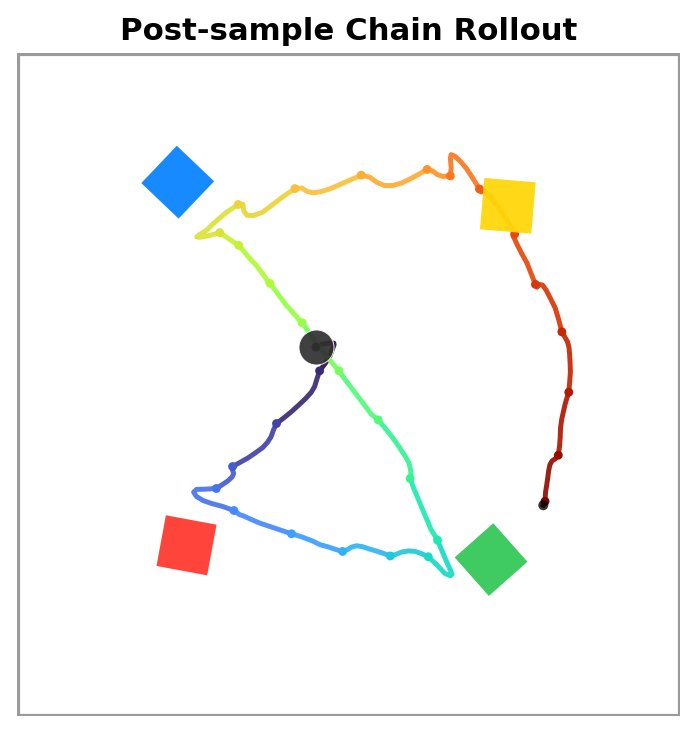

Image(value=b'GIF89a\x80\x00\x80\x00\x84\x00\x00\xff\xff\xff\xff\xff\xbf\xff\xff\x80\xff\xff@\xff\xff\x00\xbf\…

Saved post-sample chain plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/post_sample_chain_sanity/chain_2-0-1-3-0_steps20_scale0.0003_20260429_175834/post_sample_chain_rollout.png
Saved post-sample chain GIF to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/post_sample_chain_sanity/chain_2-0-1-3-0_steps20_scale0.0003_20260429_175834/post_sample_chain_rollout.gif


In [98]:
# Chain rollout with post-sample gradient guidance.



def run_post_sample_guided_chain_rollout():
    label_chain = [int(idx) for idx in POST_CHAIN_LABEL_IDXS]
    old_debug = getattr(policy.policy, "debug_guidance_actions", False)
    policy.policy.debug_guidance_actions = False

    reseed(POST_CHAIN_ENV_SEED)
    setup_state = _to_numpy(early_decision_cube_setup(deterministic=POST_CHAIN_DETERMINISTIC_SETUP)).copy()
    reseed(POST_CHAIN_ROLLOUT_SEED)
    obs = env.reset_to(setup_state)
    policy.start_episode()

    records = []
    reaches = []
    action_queue = []
    low_level_obs = [_obs_low_level_snapshot(obs)]
    frames = [_render_frame(env)]
    total_reward = 0.0
    steps = 0
    chain_pos = 0

    for t in range(int(POST_CHAIN_HORIZON)):
        if not action_queue:
            target_label_idx = label_chain[chain_pos]
            current_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))
            obs_tensor = policy._prepare_observation(obs)
            with torch.no_grad():
                base_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor).detach()
            guided_chunk_n = optimize_chunk_post_sample(
                obs_tensor,
                base_chunk_n,
                target_label_idx,
                POST_CHAIN_STEP_SIZE,
                POST_CHAIN_GUIDANCE_STEPS,
            )
            guided_chunk_raw = _unnormalize_action_sequence_torch(guided_chunk_n).detach()
            probs = _single_score_action_chunk(obs_tensor, guided_chunk_raw)[0]
            delta = guided_chunk_n - base_chunk_n
            records.append({
                "t": t,
                "stage": chain_pos,
                "target_label_idx": target_label_idx,
                "current_label": current_label["onehot"],
                "pred_probs": probs.tolist(),
                "target_score": float(probs[target_label_idx]),
                "max_da": float(delta.abs().max().detach().cpu()),
                "mean_da": float(delta.abs().mean().detach().cpu()),
                "clamp_frac": float(((guided_chunk_n.abs() >= 0.999).float().mean()).detach().cpu()),
            })
            action_queue.extend(guided_chunk_raw.detach().cpu().numpy()[0])

        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, reward, done, info = env.step(action)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        frames.append(_render_frame(env))
        total_reward += float(reward)
        steps = t + 1

        current_onehot = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
        if chain_pos < len(label_chain) and int(current_onehot[label_chain[chain_pos]]) == 1:
            reaches.append({"t": steps, "stage": chain_pos, "label_idx": label_chain[chain_pos], "label_name": LABEL_NAMES[label_chain[chain_pos]]})
            chain_pos += 1
            action_queue.clear()
            if chain_pos >= len(label_chain):
                break

    final_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
    complete = chain_pos >= len(label_chain)
    chain_names = [LABEL_NAMES[idx] for idx in label_chain]
    reached_names = [item["label_name"] for item in reaches]
    print(f"Post-sample chain target: {label_chain} ({chain_names})")
    print(f"Chain rollout finished: complete={complete}, stages={chain_pos}/{len(label_chain)}, steps={steps:03d}, return={total_reward:6.3f}")
    print(f"Reached: {reached_names}")
    print(f"{'t':>4}  {'stage':>5}  {'target':>9}  {'score':>7}  {'max|da|':>9}  {'clamp':>7}  {'current':>9}  {'pred_future_prob':>31}  {'final':>9}")
    for record in records:
        target_name = LABEL_NAMES[int(record["target_label_idx"])]
        print(
            f"{record['t']:4d}  "
            f"{record['stage']:5d}  "
            f"{target_name:>9}  "
            f"{record['target_score']:7.3f}  "
            f"{record['max_da']:9.4f}  "
            f"{record['clamp_frac']:7.3f}  "
            f"{_chain_format_onehot(record['current_label']):>9}  "
            f"{_chain_format_probs(record['pred_probs']):>31}  "
            f"{_chain_format_onehot(final_label):>9}"
        )

    chain_tag = "-".join(str(idx) for idx in label_chain)
    sanity_dir = OUTPUT_ROOT / "post_sample_chain_sanity" / f"chain_{chain_tag}_steps{POST_CHAIN_GUIDANCE_STEPS}_scale{POST_CHAIN_STEP_SIZE:g}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    sanity_dir.mkdir(parents=True, exist_ok=True)
    np.save(sanity_dir / "setup_state.npy", setup_state)
    np.savez_compressed(
        sanity_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in low_level_obs]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in low_level_obs]),
    )

    fig, ax = plt.subplots(1, 1, figsize=(4.2, 4.2), dpi=170, constrained_layout=True)
    _plot_chunk_colored_chain_rollout(ax, low_level_obs, setup_state, records)
    ax.set_title("Post-sample Chain Rollout", fontsize=13, fontweight="bold")
    plot_path = sanity_dir / "post_sample_chain_rollout.png"
    fig.savefig(plot_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    gif_path = sanity_dir / "post_sample_chain_rollout.gif"
    imageio.mimsave(gif_path, frames, duration=0.12)
    display(widgets.Image(value=gif_path.read_bytes(), format="gif", layout=widgets.Layout(width="260px")))
    print(f"Saved post-sample chain plot to {plot_path}")
    print(f"Saved post-sample chain GIF to {gif_path}")
    policy.policy.debug_guidance_actions = old_debug
    return records, reaches, complete, plot_path, gif_path


POST_CHAIN_LABEL_IDXS = [ 2, 0, 1, 3, 0]  # blue -> red -> green -> blue -> yellow -> green
POST_CHAIN_ENV_SEED = 2
POST_CHAIN_ROLLOUT_SEED = 4
POST_CHAIN_HORIZON = 400
POST_CHAIN_GUIDANCE_STEPS = 20
POST_CHAIN_STEP_SIZE = 3e-4
POST_CHAIN_DETERMINISTIC_SETUP = False
post_chain_records, post_chain_reaches, post_chain_complete, post_chain_plot_path, post_chain_gif_path = run_post_sample_guided_chain_rollout()


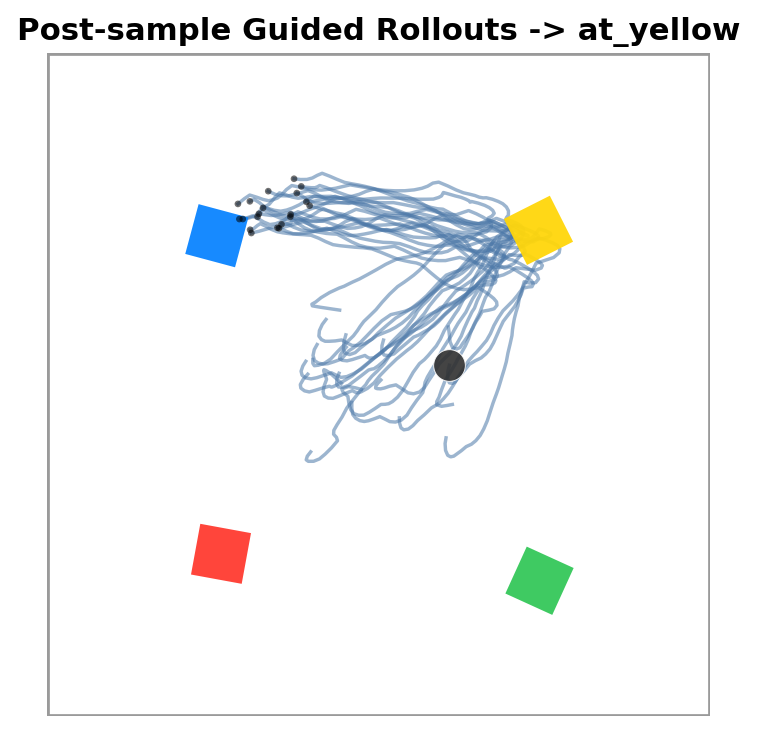

Post-sample batch: complete_rate=1.000, avg_steps=74.50
Saved overlay plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/post_sample_batch_guidance/chain_3-1_n20_steps10_scale0.0003_20260429_180719/post_sample_batch_overlay_20260429_180730.png
Output dir: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/policy_guidance/post_sample_batch_guidance/chain_3-1_n20_steps10_scale0.0003_20260429_180719


In [117]:
# Batch eval: 20 post-sample guided rollouts, original-style same-color overlay.



def _run_one_post_sample_chain(label_chain, env_seed, rollout_seed, horizon):
    label_chain = [int(idx) for idx in label_chain]
    reseed(int(env_seed))
    setup_state = _to_numpy(early_decision_cube_setup(deterministic=BATCH_POST_DETERMINISTIC_SETUP)).copy()
    reseed(int(rollout_seed))
    obs = env.reset_to(setup_state)
    policy.start_episode()
    records, reaches, action_queue = [], [], []
    low_level_obs = [_obs_low_level_snapshot(obs)]
    total_reward, steps, chain_pos = 0.0, 0, 0

    for t in range(int(horizon)):
        if not action_queue:
            target_label_idx = label_chain[chain_pos]
            current_label = label_from_low_level_obs(_obs_low_level_snapshot(obs))
            obs_tensor = policy._prepare_observation(obs)
            with torch.no_grad():
                base_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor).detach()
            guided_chunk_n = optimize_chunk_post_sample(obs_tensor, base_chunk_n, target_label_idx, BATCH_POST_STEP_SIZE, BATCH_POST_GUIDANCE_STEPS)
            guided_chunk_raw = _unnormalize_action_sequence_torch(guided_chunk_n).detach()
            probs = _single_score_action_chunk(obs_tensor, guided_chunk_raw)[0]
            delta = guided_chunk_n - base_chunk_n
            records.append({
                "t": t,
                "stage": chain_pos,
                "target_label_idx": target_label_idx,
                "current_label": current_label["onehot"],
                "pred_probs": probs.tolist(),
                "target_score": float(probs[target_label_idx]),
                "max_da": float(delta.abs().max().detach().cpu()),
                "clamp_frac": float(((guided_chunk_n.abs() >= 0.999).float().mean()).detach().cpu()),
            })
            action_queue.extend(guided_chunk_raw.detach().cpu().numpy()[0])

        action = np.asarray(action_queue.pop(0), dtype=np.float32)
        obs, reward, done, info = env.step(action)
        low_level_obs.append(_obs_low_level_snapshot(obs))
        total_reward += float(reward)
        steps = t + 1
        current_onehot = label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"]
        if chain_pos < len(label_chain) and int(current_onehot[label_chain[chain_pos]]) == 1:
            reaches.append({"t": steps, "stage": chain_pos, "label_idx": label_chain[chain_pos], "label_name": LABEL_NAMES[label_chain[chain_pos]]})
            chain_pos += 1
            action_queue.clear()
            if chain_pos >= len(label_chain):
                break
        # if done:
        #     break

    return {
        "setup_state": setup_state,
        "low_level_obs": low_level_obs,
        "records": records,
        "reaches": reaches,
        "complete": chain_pos >= len(label_chain),
        "stages": chain_pos,
        "steps": steps,
        "return": total_reward,
        "final_label": label_from_low_level_obs(_obs_low_level_snapshot(obs))["onehot"],
    }


def _save_batch_post_rollout(run_dir, rollout):
    run_dir.mkdir(parents=True, exist_ok=True)
    np.save(run_dir / "setup_state.npy", rollout["setup_state"])
    np.savez_compressed(
        run_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in rollout["low_level_obs"]]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in rollout["low_level_obs"]]),
    )
    with open(run_dir / "rollout_summary.json", "w", encoding="utf-8") as f:
        json.dump({k: rollout[k] for k in ["complete", "stages", "steps", "return", "final_label", "reaches", "records"]}, f, indent=2)


def _plot_same_color_batch_rollouts(batch_records, output_dir, title):
    palette = ["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"]
    canonical_setup = np.asarray(batch_records[0]["setup_state"], dtype=float)
    blocks = _flip_toy_square_y(canonical_setup[2:10].reshape(4, 2) / 256.0 - 1.0)
    angles = -(canonical_setup[10:14] if canonical_setup.shape[0] >= 14 else np.zeros(4))
    fig, ax = plt.subplots(1, 1, figsize=(4.2, 4.2), dpi=170, constrained_layout=True)
    for item in batch_records:
        traj = np.stack([_latest_low_level_vector(obs["agent_pos"]) for obs in item["rollout"]["low_level_obs"]], axis=0)
        traj = _flip_toy_square_y(traj)
        ax.plot(traj[:, 0], traj[:, 1], color="#4c78a8", linewidth=1.45, alpha=0.55, zorder=2)
        ax.scatter([traj[-1, 0]], [traj[-1, 1]], s=8, marker="o", c="#000000", alpha=0.55, edgecolors="none", zorder=5)
    _draw_toy_square_blocks(ax, blocks, angles, palette, radius=0.11, alpha=0.95, zorder=4)
    start_agent = _flip_toy_square_y(canonical_setup[:2] / 256.0 - 1.0)
    ax.scatter([start_agent[0]], [start_agent[1]], s=180, marker="o", c="#2f2f2f", alpha=0.9, edgecolors="white", linewidths=0.4, zorder=6)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="#9a9a9a", linewidth=2.0, zorder=10)
    ax.add_patch(frame)
    plot_path = output_dir / f"post_sample_batch_overlay_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    fig.savefig(plot_path, bbox_inches="tight")
    return fig, plot_path


def run_batch_post_sample_guided_rollouts():
    old_debug = getattr(policy.policy, "debug_guidance_actions", False)
    policy.policy.debug_guidance_actions = False
    label_chain = [int(idx) for idx in BATCH_POST_LABEL_IDXS]
    chain_tag = "-".join(str(idx) for idx in label_chain)
    output_dir = OUTPUT_ROOT / "post_sample_batch_guidance" / f"chain_{chain_tag}_n{BATCH_POST_N_ROLLOUTS}_steps{BATCH_POST_GUIDANCE_STEPS}_scale{BATCH_POST_STEP_SIZE:g}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    output_dir.mkdir(parents=True, exist_ok=True)
    batch_records = []
    for rollout_idx in range(int(BATCH_POST_N_ROLLOUTS)):
        rollout = _run_one_post_sample_chain(label_chain, BATCH_POST_ENV_SEEDS[rollout_idx], BATCH_POST_ROLLOUT_SEEDS[rollout_idx], BATCH_POST_HORIZON)
        run_dir = output_dir / f"rollout_{rollout_idx:03d}"
        _save_batch_post_rollout(run_dir, rollout)
        batch_records.append({"rollout_idx": rollout_idx, "env_seed": int(BATCH_POST_ENV_SEEDS[rollout_idx]), "rollout_seed": int(BATCH_POST_ROLLOUT_SEEDS[rollout_idx]), "complete": rollout["complete"], "steps": rollout["steps"], "return": rollout["return"], "run_dir": str(run_dir), "setup_state": rollout["setup_state"], "rollout": rollout})
    complete_rate = float(np.mean([item["complete"] for item in batch_records]))
    avg_steps = float(np.mean([item["steps"] for item in batch_records]))
    summary = {"label_chain": label_chain, "label_names": [LABEL_NAMES[idx] for idx in label_chain], "n_rollouts": int(BATCH_POST_N_ROLLOUTS), "complete_rate": complete_rate, "avg_steps": avg_steps, "guidance_steps": int(BATCH_POST_GUIDANCE_STEPS), "step_size": float(BATCH_POST_STEP_SIZE), "output_dir": str(output_dir)}
    with open(output_dir / "batch_summary.json", "w", encoding="utf-8") as f:
        json.dump({**summary, "records": [{k: v for k, v in item.items() if k not in {"setup_state", "rollout"}} for item in batch_records]}, f, indent=2)
    fig, plot_path = _plot_same_color_batch_rollouts(batch_records, output_dir, f"Post-sample Guided Rollouts -> {LABEL_NAMES[label_chain[0]]}")
    display(fig)
    plt.close(fig)
    print(f"Post-sample batch: complete_rate={complete_rate:.3f}, avg_steps={avg_steps:.2f}")
    print(f"Saved overlay plot to {plot_path}")
    print(f"Output dir: {output_dir}")
    policy.policy.debug_guidance_actions = old_debug
    return summary, batch_records, plot_path


BATCH_POST_LABEL_IDXS = [3, 1]  # start with blue
BATCH_POST_N_ROLLOUTS = 20
BATCH_POST_ENV_SEEDS = list(range(BATCH_POST_N_ROLLOUTS))
BATCH_POST_ROLLOUT_SEEDS = list(range(BATCH_POST_N_ROLLOUTS))
BATCH_POST_HORIZON = 200
BATCH_POST_GUIDANCE_STEPS = 10
BATCH_POST_STEP_SIZE = 3e-4
BATCH_POST_DETERMINISTIC_SETUP = False

batch_post_summary, batch_post_records, batch_post_plot_path = run_batch_post_sample_guided_rollouts()
